# Outlier

In [ ]:
# 👉 Data me jo value baaki sab se bahut alag (extreme) ho
# 👉 usse outlier bolte hain

# 🔍 Example:
# Marks → [40, 42, 45, 43, 100]

# 👉 Yaha:
# 40–45 normal values
# 100 = outlier ❗

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\archive\AI Job Market Dataset.csv")
df

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9


In [3]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


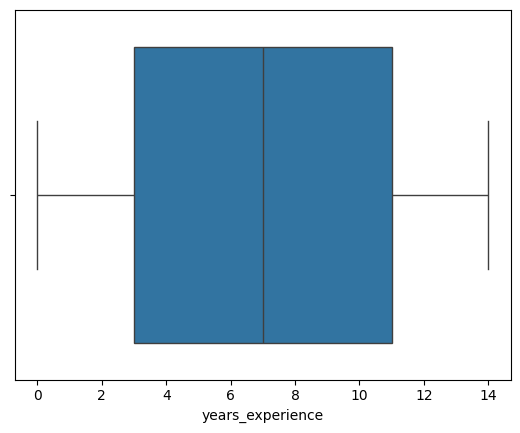

In [8]:
sns.boxplot(x = "years_experience", data=df)
plt.show()

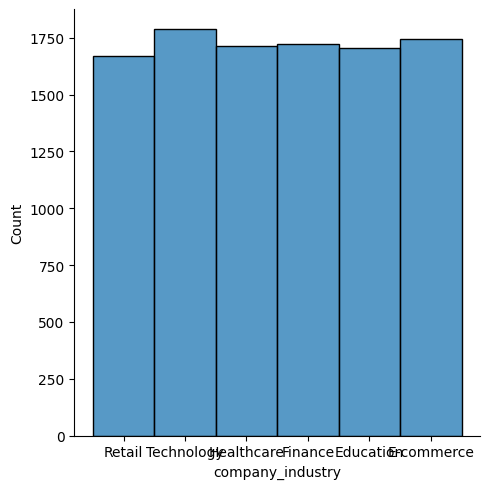

In [ ]:
sns.displot(df["company_industry"])
plt.show()
# displot() hamesha new window/figure banata hai
# isko combine karna mushkil hota hai

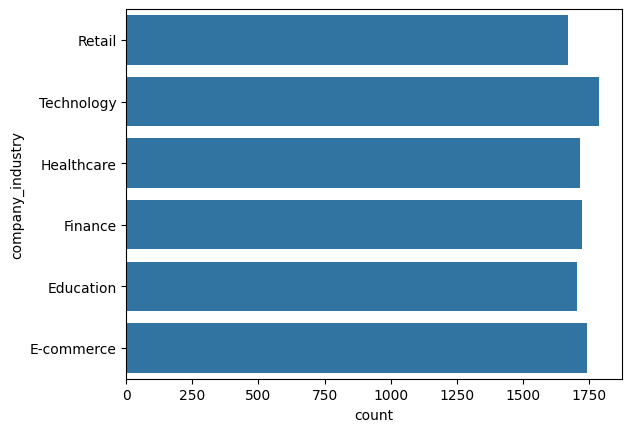

In [15]:
sns.countplot(df["company_industry"])
plt.show()

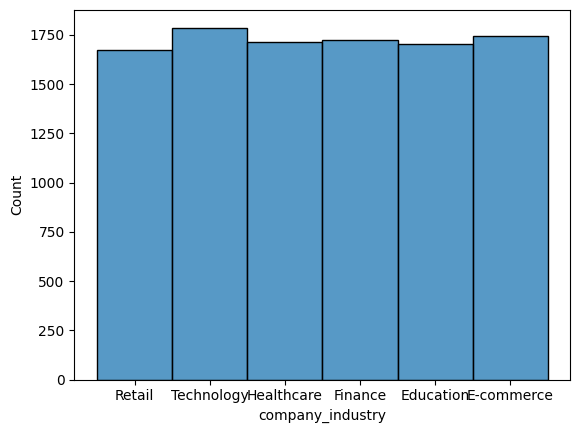

In [17]:
sns.histplot(df["company_industry"])
plt.show()

In [18]:
l = [5, 6, 7, 5, 4, 6, 7, 5]
sum(l)/len(l)

5.625

In [ ]:
l = [5, 6, 7, 5, 4, 6, 7, 5, 100]   # 100 is Outlier, here 
sum(l)/len(l)

16.11111111111111

In [21]:
q1 = df["years_experience"].quantile(0.25)
q3 = df["years_experience"].quantile(0.75)
q3

np.float64(11.0)

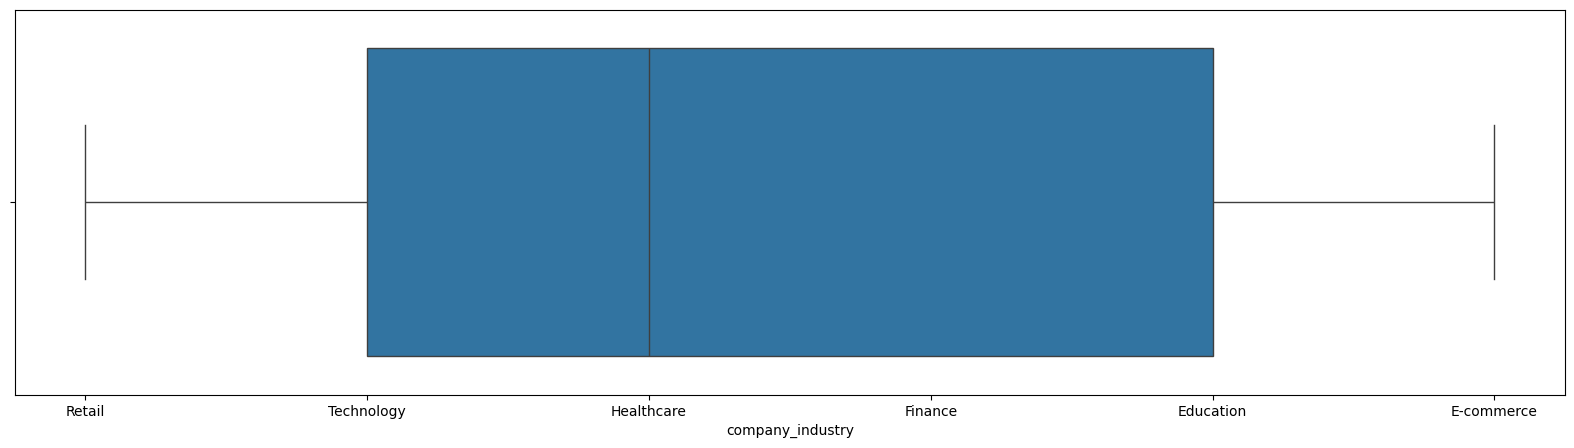

In [ ]:
plt.figure(figsize=(20, 5))  # figsize=(width, height) 
sns.boxplot(x="company_industry", data=df)
plt.show()

In [27]:
df.shape

(10345, 19)

In [28]:
IQR = q3-q1

In [ ]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range, max_range

(np.float64(-9.0), np.float64(-1.0))

In [35]:
new_df = df[df["years_experience"]<=max_range]

In [37]:
new_df.shape

(0, 19)

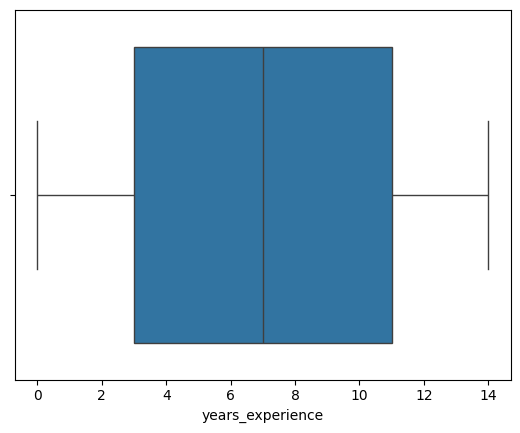

In [38]:
sns.boxplot(x="years_experience", data=df)
plt.show()

# Outlier removal using Z score

In [49]:
# salary column ka mean (average value) nikal rahe hain
mean = df["salary"].mean()

# salary column ka standard deviation (data kitna spread hai) nikal rahe hain
std = df["salary"].std()

# lower limit (minimum range)
# mean se 3 * std subtract kar rahe hain → iske neeche wale values outliers ho sakte hain
min_range = mean - (3 * std)

# upper limit (maximum range)
# mean me 3 * std add kar rahe hain → iske upar wale values outliers ho sakte hain
max_range = mean + (3 * std)

In [50]:
min_range, max_range

(np.float64(19270.62407987837), np.float64(207605.83043921296))

In [52]:
new_data =df[df["salary"]<=max_range]

<Axes: xlabel='salary'>

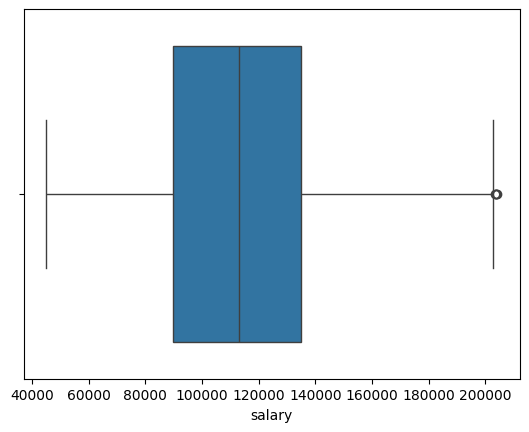

In [54]:
sns.boxplot(x = "salary", data=new_data)

In [58]:
# salary column ka z-score calculate kar rahe hain
# formula: (value - mean) / standard deviation

z_score = (df["salary"] - df["salary"].mean()) / (df["salary"].std())

In [59]:
z_score

0        1.429911
1        1.600161
2        1.437366
3       -0.562717
4       -0.049865
           ...   
10340   -1.179139
10341   -1.663159
10342   -0.310847
10343   -0.017306
10344    1.469670
Name: salary, Length: 10345, dtype: float64

In [60]:
z_score > 3

0        False
1        False
2        False
3        False
4        False
         ...  
10340    False
10341    False
10342    False
10343    False
10344    False
Name: salary, Length: 10345, dtype: bool

In [61]:
df["z_score"] = z_score

In [62]:
df

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings,z_score
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4,1.429911
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9,1.600161
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9,1.437366
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7,-0.562717
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2,-0.049865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4,-1.179139
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6,-1.663159
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4,-0.310847
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9,-0.017306


In [63]:
df[df["z_score"] < 3]

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings,z_score
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4,1.429911
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9,1.600161
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9,1.437366
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7,-0.562717
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2,-0.049865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4,-1.179139
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6,-1.663159
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4,-0.310847
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9,-0.017306


In [64]:
df.shape

(10345, 20)

In [65]:
df[df["z_score"] < 3].shape

(10345, 20)